# Assignment 4 – Pokemon Analysis
## 1. Distance Function: PCA + Euclidean

We project all Pokemon into a lower-dimensional space via **PCA** and then compute pairwise **Euclidean distances** in that space. PCA keeps the directions of largest variance and drops noise, so distances reflect the dominant patterns in stats + types.

Features used:
- Battle stats: `HP`, `attack`, `defense`, `sp. attack`, `sp. defense`, `speed` (standardized)
- Type one-hot columns: `type_fire`, `type_water`, ..., `type_fairy`

In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

df = pd.read_csv("pokedex.csv")
df.head()

,id,name,HP,attack,defense,sp. attack,sp. defense,speed,species,description,...,type_ground,type_flying,type_psychic,type_bug,type_rock,type_ghost,type_dragon,type_dark,type_steel,type_fairy
0,1,Bulbasaur,45,49,49,65,65,45,Seed Pokémon,Bulbasaur can be seen napping in bright sunlig...,...,0,0,0,0,0,0,0,0,0,0
1,2,Ivysaur,60,62,63,80,80,60,Seed Pokémon,There is a bud on this Pokémon’s back. To supp...,...,0,0,0,0,0,0,0,0,0,0
2,3,Venusaur,80,82,83,100,100,80,Seed Pokémon,There is a large flower on Venusaur’s back. Th...,...,0,0,0,0,0,0,0,0,0,0
3,4,Charmander,39,52,43,60,50,65,Lizard Pokémon,The flame that burns at the tip of its tail is...,...,0,0,0,0,0,0,0,0,0,0
4,5,Charmeleon,58,64,58,80,65,80,Flame Pokémon,Charmeleon mercilessly destroys its foes using...,...,0,0,0,0,0,0,0,0,0,0


In [3]:
stat_cols = ["HP", "attack", "defense", "sp. attack", "sp. defense", "speed"]
type_cols = [c for c in df.columns if c.startswith("type_")]

stats_scaled = StandardScaler().fit_transform(df[stat_cols])
types = df[type_cols].to_numpy(dtype=float)

W_STATS, W_TYPES = 1.5, 1.0
X = np.hstack([W_STATS * stats_scaled, W_TYPES * types])
X.shape

(898, 23)

In [4]:
distance = pairwise_distances(X, metric="euclidean")

dist_df = pd.DataFrame(distance, index=df["name"], columns=df["name"])
dist_df.iloc[:10, :10].round(3)

name,Bulbasaur,Ivysaur,Venusaur,Charmander,Charmeleon,Charizard,Squirtle,Wartortle,Blastoise,Caterpie
name,,,,,,,,,,
Bulbasaur,0.000,1.893,4.491,2.259,2.887,5.251,2.066,2.790,5.046,3.994
Ivysaur,1.893,0.000,2.599,3.101,2.212,3.689,2.880,2.085,3.425,5.431
Venusaur,4.491,2.599,0.000,5.239,3.442,2.471,5.037,3.342,2.104,7.728
Charmander,2.259,3.101,5.239,0.000,2.120,5.022,2.362,3.182,5.432,3.404
Charmeleon,2.887,2.212,3.442,2.120,0.000,2.985,3.096,2.425,3.731,5.092
Charizard,5.251,3.689,2.471,5.022,2.985,0.000,5.480,3.919,2.887,7.805
Squirtle,2.066,2.880,5.037,2.362,3.096,5.480,0.000,1.974,4.701,3.671
Wartortle,2.790,2.085,3.342,3.182,2.425,3.919,1.974,0.000,2.729,5.244
Blastoise,5.046,3.425,2.104,5.432,3.731,2.887,4.701,2.729,0.000,7.759


# Clustering



In [5]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    metric="precomputed",
    min_cluster_size=15,
    min_samples=1,
).fit(distance.astype(np.float64))

df["hdb_cluster"] = hdb.labels_

n_clusters = (hdb.labels_.max() + 1) if hdb.labels_.max() >= 0 else 0
n_noise = int((hdb.labels_ == -1).sum())
print(f"HDBSCAN on distance matrix → {n_clusters} clusters, {n_noise} noise points")
print(pd.Series(hdb.labels_).value_counts().sort_index())

HDBSCAN on distance matrix → 4 clusters, 598 noise points
-1    598
 0     15
 1     22
 2    237
 3     26
Name: count, dtype: int64


/Users/ericbuchinger/Library/CloudStorage/OneDrive-FHOOe/2. Semester/DAM2/Uebungen/04/.venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ericbuchinger/Library/CloudStorage/OneDrive-FHOOe/2. Semester/DAM2/Uebungen/04/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


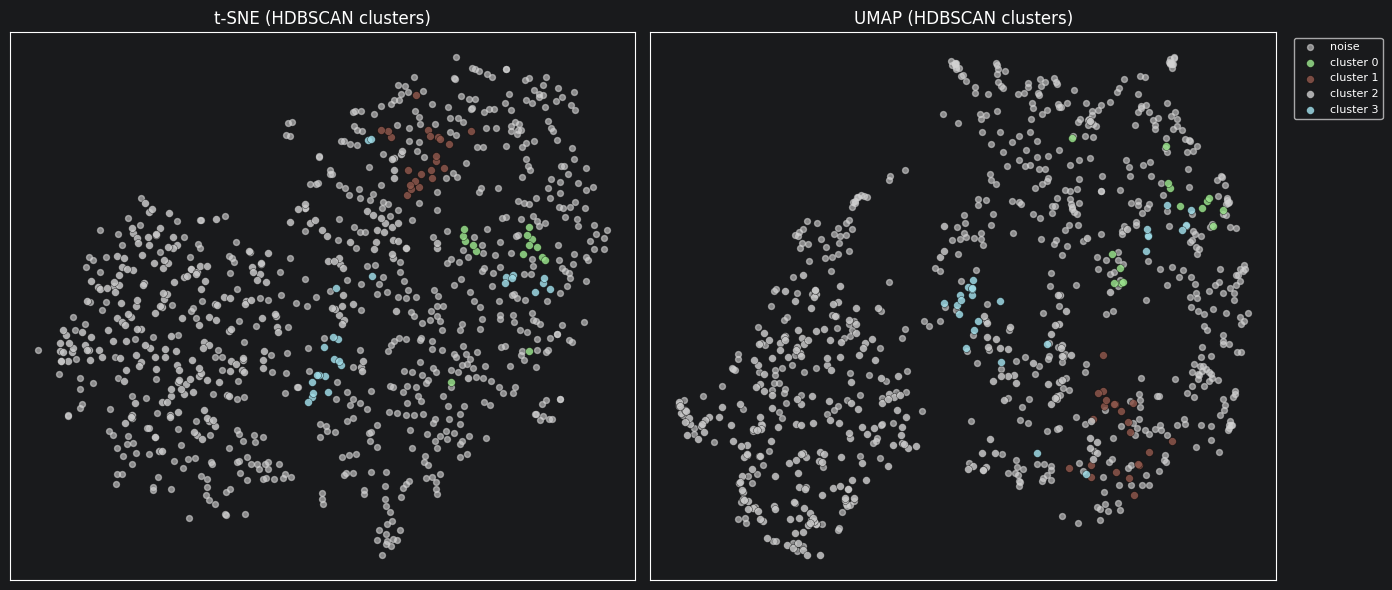

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

tsne_2d = TSNE(
    n_components=2, metric="precomputed", init="random",
    perplexity=30, learning_rate="auto", random_state=0,
).fit_transform(distance)

umap_2d = umap.UMAP(
    n_components=2, metric="precomputed",
    n_neighbors=15, min_dist=0.1, random_state=0,
).fit_transform(distance)

labels = df["hdb_cluster"].to_numpy()
unique = sorted(set(labels))
cmap = plt.get_cmap("tab20", max(len(unique), 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], tsne_2d, "t-SNE"), (axes[1], umap_2d, "UMAP")]:
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c="lightgray", s=18, alpha=0.6, label="noise")
        else:
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[cmap(i)], s=32, alpha=0.85,
                       edgecolors="k", linewidths=0.3, label=f"cluster {lbl}")
    ax.set_title(f"{title} (HDBSCAN clusters)")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Silhouette Score

Bewertung der HDBSCAN-Clusterqualität. Noise-Punkte (Label `-1`) werden ausgeschlossen, der Score wird auf der precomputed Distanzmatrix berechnet. Werte: **-1** (schlecht) … **0** (überlappend) … **+1** (klar getrennt).

In [60]:
from sklearn.metrics import silhouette_score, silhouette_samples

mask = labels != -1
n_clusters = len(set(labels[mask]))

if n_clusters >= 2:
    sub_dist = distance[np.ix_(mask, mask)]
    sub_labels = labels[mask]

    score = silhouette_score(sub_dist, sub_labels, metric="precomputed")
    sample_scores = silhouette_samples(sub_dist, sub_labels, metric="precomputed")

    print(f"Silhouette score (HDBSCAN, ohne Noise): {score:.3f}")
    print(f"Cluster: {n_clusters}, bewertete Punkte: {mask.sum()} / {len(labels)} "
          f"(Noise: {(~mask).sum()})\n")

    per_cluster = (
        pd.DataFrame({"cluster": sub_labels, "silhouette": sample_scores})
        .groupby("cluster")["silhouette"].agg(["mean", "count"])
        .round(3)
    )
    print("Pro Cluster:")
    print(per_cluster)
else:
    print("Zu wenige Cluster für Silhouette-Score (mind. 2 nötig).")

Silhouette score (HDBSCAN, ohne Noise): 0.245
Cluster: 3, bewertete Punkte: 43 / 898 (Noise: 855)

Pro Cluster:
          mean  count
cluster              
0        0.093     16
1        0.372     12
2        0.305     15
